In [3]:
import glob
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import MaxNLocator

import os
while not os.path.isdir('.git'):
    os.chdir('../..')

import matplotlib as mpl
mpl.rcParams["font.family"] = "Avenir"

In [4]:
subthreshold = []

for file in glob.glob("output/temporal-interference/ef/*_*_*.csv"):
    pattern = re.compile(r"([^/]+)_([^/]+)_([^/]+)\.csv$")
    phi, psi, carrier = pattern.search(file).groups()

    data = pd.read_csv(file)
    data["Phi"] = int(phi)
    data["Psi"] = int(psi)
    data["Carrier"] = int(carrier)

    subthreshold.append(data)

subthreshold = pd.concat(subthreshold, ignore_index = True)

In [5]:
subthreshold

,Offset,Amplitude,Phi,Psi,Carrier
0,0.0,877.197266,0,180,1000
1,0.5,295.166016,0,180,1000
2,1.0,254.882812,0,180,1000
3,2.0,254.150391,0,180,1000
4,3.0,252.929688,0,180,1000
...,...,...,...,...,...
246,90.0,898.925781,90,90,9000
247,100.0,901.367188,90,90,9000
248,110.0,904.541016,90,90,9000
249,120.0,906.738281,90,90,9000


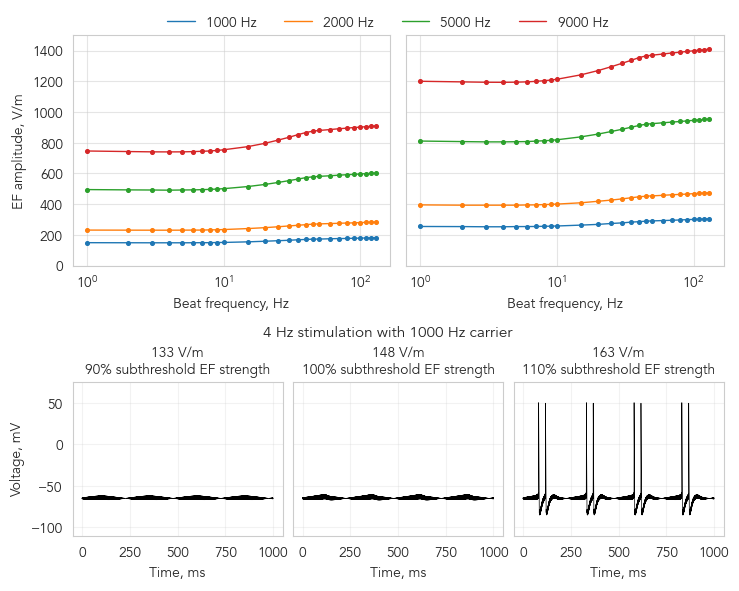

In [8]:
fig = plt.figure(figsize = (8.4, 6.5))

outer_gs = gridspec.GridSpec(3, 1, height_ratios = [1.2, 0.3, 0.8])

# --- B panel (1 row, 2 plots) ---
inner_gs = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec = outer_gs[0], wspace = 0.05, width_ratios = [1, 1])
ax_b1 = fig.add_subplot(inner_gs[0])
ax = ax_b1

carriers = [1000, 2000, 5000, 9000]
colors = {
    1000: "tab:blue",
    2000: "tab:orange",
    5000: "tab:green",
    9000: "tab:red"
}

for carrier in carriers:
    dt = subthreshold[
        (subthreshold.Phi == 90) &
        (subthreshold.Psi == 90) &
        (subthreshold.Carrier == carrier) &
        (subthreshold.Offset > 0.5)
        ]

    color = colors[carrier]

    ax.plot(dt.Offset, dt.Amplitude, linewidth = 1, label = f"{carrier} Hz", color = color)
    ax.scatter(dt.Offset, dt.Amplitude, s = 7, color = color)

ax.set_xlabel("Beat frequency, Hz")
ax.set_ylabel("EF amplitude, V/m")
ax.set_xscale("log")
ax.grid(alpha = 0.5)
ax.set_ylim(0, 1500)

ax_b2 = fig.add_subplot(inner_gs[1])
ax = ax_b2

for carrier in carriers:
    dt = subthreshold[
        (subthreshold.Phi == 0) &
        (subthreshold.Psi == 180) &
        (subthreshold.Carrier == carrier) &
        (subthreshold.Offset > 0.5)
        ]

    color = colors[carrier]

    ax.plot(dt.Offset, dt.Amplitude, linewidth = 1, color = color)
    ax.scatter(dt.Offset, dt.Amplitude, s = 7, color = color)

ax.set_xlabel("Beat frequency, Hz")
ax.set_xscale("log")
ax.grid(alpha = 0.5)
ax.set_ylim(0, 1500)
ax.tick_params(left = False, labelleft = False)

fig.legend(loc = "upper center", ncol = 4, frameon = False, bbox_to_anchor = (0.5, 0.93))

# --- C panel (1 row title + 3 horizontal plots) ---
inner_gs = gridspec.GridSpecFromSubplotSpec(1, 3, subplot_spec = outer_gs[2], wspace = 0.05)
ax_d1 = fig.add_subplot(inner_gs[0])
ax_d2 = fig.add_subplot(inner_gs[1])
ax_d3 = fig.add_subplot(inner_gs[2])

axs = [ax_d1, ax_d2, ax_d3]

voltage0_9 = pd.read_csv("output/temporal-interference-1/figures/figure1/voltage_trace_1000_4Hz_0.9.csv")
voltage1 = pd.read_csv("output/temporal-interference-1/figures/figure1/voltage_trace_1000_4Hz_1.csv")
voltage1_1 = pd.read_csv("output/temporal-interference-1/figures/figure1/voltage_trace_1000_4Hz_1.1.csv")

for ax, voltage in zip(axs, [voltage0_9, voltage1, voltage1_1]):
    ax.plot(
        voltage.Time,
        voltage.Voltage,
        color = "black",
        linewidth = 0.5
    )

    ax.set_ylim(-110, 75)
    ax.set_xlabel("Time, ms")
    ax.grid(alpha = 0.25)

axs[1].tick_params(left = False, labelleft = False)
axs[2].tick_params(left = False, labelleft = False)

axs[0].set_title("133 V/m\n90% subthreshold EF strength", fontsize = 10)
axs[1].set_title("148 V/m\n100% subthreshold EF strength", fontsize = 10)
axs[2].set_title("163 V/m\n110% subthreshold EF strength", fontsize = 10)

axs[0].yaxis.set_visible(True)
axs[0].set_ylabel("Voltage, mV")

fig.text(
    0.5, 0.41,
    "4 Hz stimulation with 1000 Hz carrier",
    ha = "center",
    va = "bottom",
    fontsize = 11
)

# fig.text(0.04, 0.905, "B", fontsize = 12)
# fig.text(0.04, 0.42, "C", fontsize = 12)

plt.savefig("cns_2025_figure1.png", dpi = 2500, bbox_inches = "tight")